<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/ML-Projects/vgg_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 4

In [ ]:
!ls

cnn_dataset  cnn_dataset.zip  dataset.csv  datasets.zip  sample_data


In [ ]:
!unzip -q "datasets"

replace cnn_dataset.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

##Importing and unzipping dataset


In [ ]:
!unzip -q "cnn_dataset.zip"

replace cnn_dataset/0/100027.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!ls

cnn_dataset  cnn_dataset.zip  dataset.csv  datasets.zip  sample_data


##Transforming our dataset images and splitting the data

In [ ]:
#Splitting

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

data_dir = 'cnn_dataset'


# transform = transforms.Compose([
#     transforms.Resize((64,64)),
#     transforms.RandomRotation(10),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64,64)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)
num_classes = len(full_dataset.classes)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])




In [ ]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:

torch.manual_seed(42)

###Creating vgg model

In [ ]:
cfg_vgg13 = [64, 64, 'M',
             128, 128, 'M',
             256, 256, 'M',
             512, 512, 'M']

In [ ]:
class VGG(nn.Module):
    def __init__(self, cfg, in_channels=1, num_classes=36, dropout=0.5):
        super(VGG, self).__init__()
        self.features = self._make_layers(cfg, in_channels)
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.dropout_rate = dropout
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(p=self.dropout_rate),
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(p=self.dropout_rate),
            nn.Linear(512, self.num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = nn.AdaptiveAvgPool2d((1, 1))(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _make_layers(self, cfg, in_channels):
        layers = []
        for v in cfg:
            if v == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [
                    nn.Conv2d(in_channels, v, kernel_size=3, padding=1),
                    nn.BatchNorm2d(v),
                    nn.ReLU(inplace=True)
                ]
                in_channels = v
        return nn.Sequential(*layers)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
model = VGG(cfg_vgg13, in_channels=1, num_classes=num_classes).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

In [ ]:
num_epochs = 20
train_losses, train_accs = [], []
val_losses, val_accs = [], []
test_losses, test_accs = [], []


y_true_test, y_pred_test, y_probs_test = [], [], []

for epoch in range(num_epochs):

    model.train()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)


    model.eval()
    running_val_loss, correct_val, total_val = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)


    running_test_loss, correct_test, total_test = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)


            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(preds.cpu().numpy())
            y_probs_test.extend(torch.softmax(outputs, dim=1).cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test
    test_losses.append(epoch_test_loss)
    test_accs.append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Acc: {epoch_train_acc:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f} | "
          f"Test Acc: {epoch_test_acc:.4f}")


Epoch [1/20] | Train Acc: 0.6597 | Val Acc: 0.8117 | Test Acc: 0.8058
Epoch [2/20] | Train Acc: 0.8443 | Val Acc: 0.8587 | Test Acc: 0.8565
Epoch [3/20] | Train Acc: 0.8618 | Val Acc: 0.8832 | Test Acc: 0.8831
Epoch [4/20] | Train Acc: 0.8698 | Val Acc: 0.8815 | Test Acc: 0.8788
Epoch [5/20] | Train Acc: 0.8783 | Val Acc: 0.8829 | Test Acc: 0.8813
Epoch [6/20] | Train Acc: 0.8816 | Val Acc: 0.8833 | Test Acc: 0.8832
Epoch [7/20] | Train Acc: 0.8863 | Val Acc: 0.9019 | Test Acc: 0.9007
Epoch [8/20] | Train Acc: 0.8907 | Val Acc: 0.9026 | Test Acc: 0.9038
Epoch [9/20] | Train Acc: 0.8929 | Val Acc: 0.8962 | Test Acc: 0.8942
Epoch [10/20] | Train Acc: 0.8958 | Val Acc: 0.8990 | Test Acc: 0.8960
Epoch [11/20] | Train Acc: 0.8960 | Val Acc: 0.9056 | Test Acc: 0.9055
Epoch [12/20] | Train Acc: 0.8999 | Val Acc: 0.9118 | Test Acc: 0.9120
Epoch [13/20] | Train Acc: 0.9005 | Val Acc: 0.9056 | Test Acc: 0.9021
Epoch [14/20] | Train Acc: 0.9006 | Val Acc: 0.9045 | Test Acc: 0.9051
Epoch [15/20] |

In [ ]:
def plot_all_metrics(train_losses, val_losses, test_losses,
                     train_accs, val_accs, test_accs,
                     y_true_test, y_pred_test, y_probs_test,
                     num_classes=36):

    #Loss curve
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    #Accuracy curve
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Validation Acc')
    plt.plot(test_accs, label='Test Acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.show()

    #Confusion Matrix on test
    cm = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Test Set')
    plt.show()

    #ROC Curve on test
    y_true_bin = label_binarize(y_true_test, classes=list(range(num_classes)))

    plt.figure(figsize=(10,8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_test[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.2f})")

    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves - Test Set")
    plt.legend(loc="lower right", fontsize='small', ncol=2)
    plt.show()

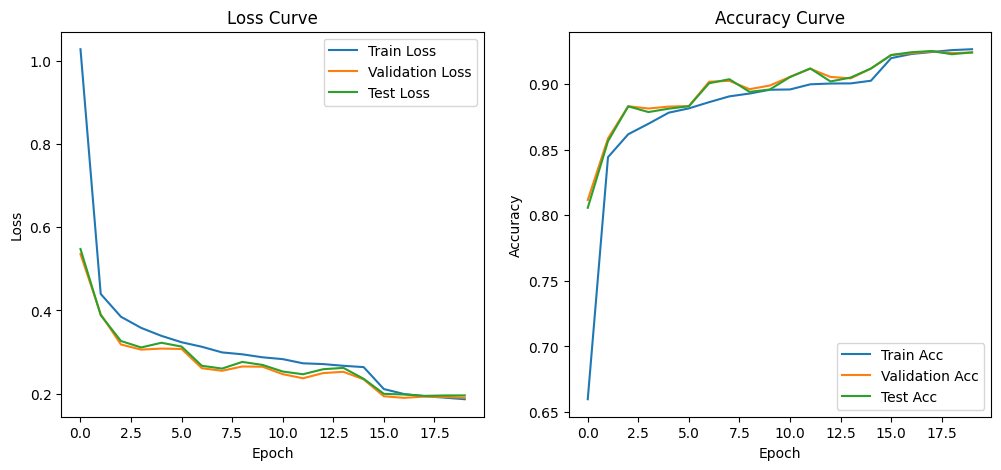

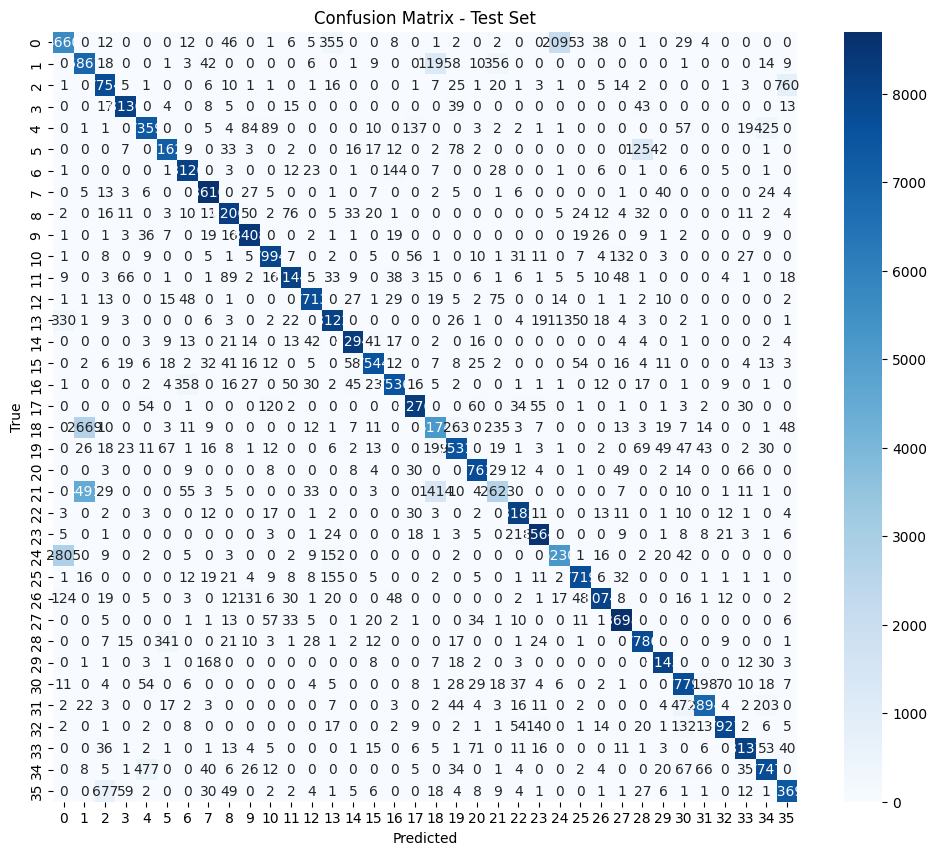

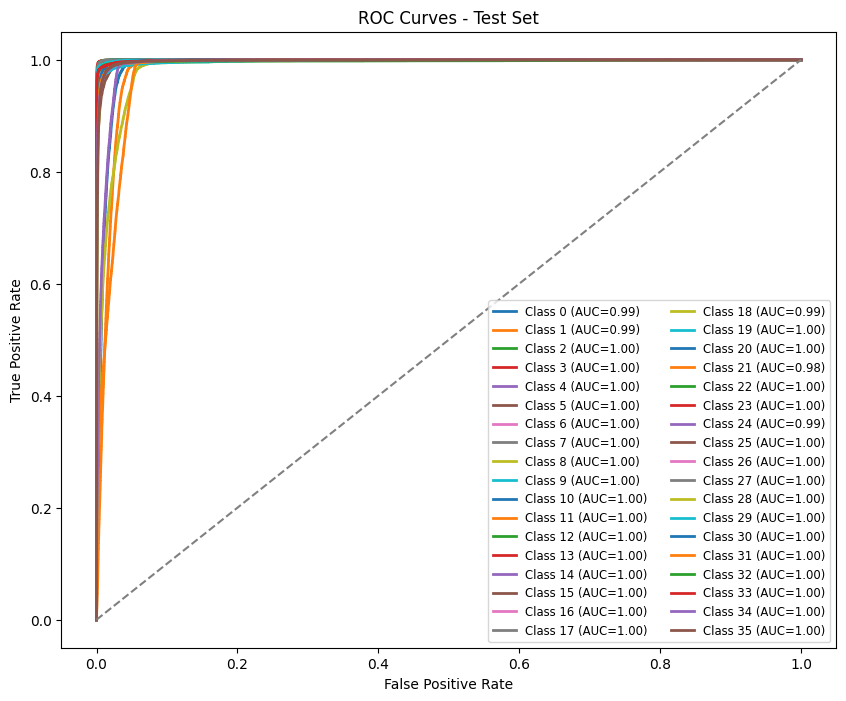

In [ ]:
plot_all_metrics(
    train_losses, val_losses, test_losses,
    train_accs, val_accs, test_accs,
    y_true_test, y_pred_test, np.array(y_probs_test),
    num_classes=36
)


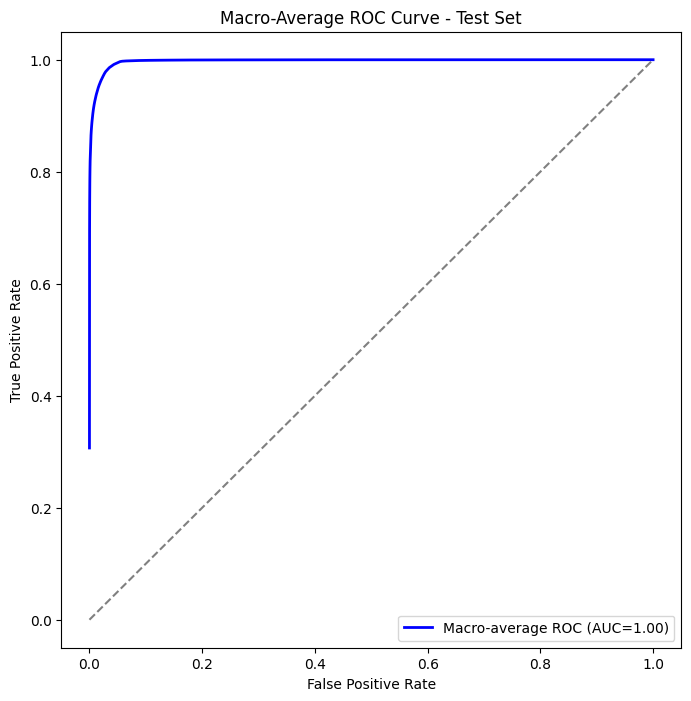

In [ ]:

y_true_bin = label_binarize(y_true_test, classes=list(range(num_classes)))
y_probs_test = np.array(y_probs_test)


fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

macro_auc = auc(all_fpr, mean_tpr)

# Plot
plt.figure(figsize=(8,8))
plt.plot(all_fpr, mean_tpr, color='b', lw=2, label=f"Macro-average ROC (AUC={macro_auc:.2f})")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# test_accuracy = test_accs[-1]
# print(f"\n Test Accuracy: {test_accuracy*100:.2f}%")

# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(12,10))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

In [ ]:
# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# plt.plot(train_losses, label='Train Loss')
# plt.plot(test_losses, label='Test Loss')
# plt.legend()
# plt.title('Loss Curve')


In [ ]:
# plt.subplot(1,2,2)
# plt.plot(train_accs, label='Train Acc')
# plt.plot(test_accs, label='Test Acc')
# plt.legend()
# plt.title('Accuracy Curve')
# plt.show()

In [ ]:
# #ROC curve

# y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# plt.figure(figsize=(12,10))
# for i in range(num_classes):
#     fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
#     roc_auc = auc(fpr, tpr)
#     plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.2f})")

# plt.plot([0,1], [0,1], '--', color='gray')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curves - Original VGG Model")
# plt.legend(loc="lower right", fontsize='small', ncol=2)
# plt.show()

In [ ]:
# # if we want to plot for just one class we can change the index and plot
# class_index = 0
# y_true_class = y_true_bin[:, class_index]
# y_score_class = y_probs[:, class_index]


# fpr, tpr, _ = roc_curve(y_true_class, y_score_class)
# roc_auc = auc(fpr, tpr)


# plt.figure(figsize=(8,6))
# plt.plot(fpr, tpr, color='blue', lw=2, label=f'Class {class_index} ROC (AUC = {roc_auc:.2f})')
# plt.plot([0,1], [0,1], 'k--', lw=2)
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title(f"ROC Curve - Class {class_index}")
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# #micro averaging- just one line for all classes
# fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
# roc_auc_micro = auc(fpr_micro, tpr_micro)

# # Plot
# plt.figure(figsize=(8,6))
# plt.plot(fpr_micro, tpr_micro, color='blue', lw=2, label=f'Micro-average ROC (AUC = {roc_auc_micro:.2f})')
# plt.plot([0,1], [0,1], 'k--', lw=2)  # random guess line
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("Micro-average ROC Curve - All Classes")
# plt.legend(loc="lower right")
# plt.show()

##Further optimizing as per our instructions of step 4

##We can reuse our old code and write generic training part such that just change the parameters

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

def train_vgg(
    train_loader, val_loader, test_loader,
    optimizer_type='adam',
    dropout_rate=0.5,
    lr=0.001,
    weight_decay=5e-4,
    scheduler_step=10,
    scheduler_gamma=0.1,
    early_stopping=True,
    patience=7,
    num_epochs=20,
    model_name="model",
    in_channels=1,
    num_classes=36
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    model = VGG(cfg_vgg13, in_channels=in_channels, num_classes=num_classes, dropout=dropout_rate).to(device)


    criterion = nn.CrossEntropyLoss()


    optimizer_type = optimizer_type.lower()
    if optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_type == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_type}")


    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=scheduler_gamma)


    best_test_loss = np.inf
    trigger_times = 0


    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    test_losses, test_accs = [], []

    y_true, y_pred, y_probs = [], [], []

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0


        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        scheduler.step()

        model.eval()
        running_val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = running_val_loss / total_val
        val_acc = correct_val / total_val
        val_losses.append(val_loss)
        val_accs.append(val_acc)


        running_test_loss, correct_test, total_test = 0, 0, 0
        y_true_epoch, y_pred_epoch, y_probs_epoch = [], [], []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct_test += (preds == labels).sum().item()
                total_test += labels.size(0)

                y_true_epoch.extend(labels.cpu().numpy())
                y_pred_epoch.extend(preds.cpu().numpy())
                y_probs_epoch.extend(torch.softmax(outputs, dim=1).cpu().numpy())

        test_loss = running_test_loss / total_test
        test_acc = correct_test / total_test
        test_losses.append(test_loss)
        test_accs.append(test_acc)


        y_true, y_pred, y_probs = y_true_epoch, y_pred_epoch, y_probs_epoch

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Test Loss: {test_loss:.4f}")


        if early_stopping:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1} based on test loss")
                    break

    end_time = time.time()
    total_time = end_time - start_time

    return {
        "model_name": model_name,
        "optimizer": optimizer_type,
        "dropout": dropout_rate,
        "train_acc": train_accs,
        "val_acc": val_accs,
        "test_acc": test_accs,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "test_loss": test_losses,
        "best_val_acc": max(val_accs),
        "time": total_time,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probs": y_probs,
        "model": model
    }


##generic plot too so we avoid re-writing everything again

In [ ]:
def plot_model_results(metrics, num_classes=36, device='cuda'):
    #loss curve
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(metrics['train_loss'], label='Train Loss')
    plt.plot(metrics['val_loss'], '--', label='Validation Loss')
    plt.plot(metrics['test_loss'], ':', label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {metrics['model_name']}")
    plt.legend()

    #accuracy
    plt.subplot(1,2,2)
    plt.plot(metrics['train_acc'], label='Train Acc')
    plt.plot(metrics['val_acc'], '--', label='Validation Acc')
    plt.plot(metrics['test_acc'], ':', label='Test Acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curve - {metrics['model_name']}")
    plt.legend()
    plt.show()

    #confusion
    cm = confusion_matrix(metrics['y_true'], metrics['y_pred'])
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {metrics["model_name"]}')
    plt.show()

    #ROC
    y_true_bin = label_binarize(metrics['y_true'], classes=list(range(num_classes)))
    y_probs = np.array(metrics['y_probs'])

    plt.figure(figsize=(12,10))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.2f})")

    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {metrics['model_name']}")
    plt.legend(loc="lower right", fontsize='small', ncol=2)
    plt.show()


##testing out with different hyperparamter

In [ ]:
#different optimizer
optimizer_hyperparameter = [
    {"name": "ADAM_0.5", "dropout": 0.5, "optimizer": "adam", "lr": 0.001, "early_stop": False},
    {"name": "SGD_0.5", "dropout": 0.5, "optimizer": "sgd", "lr": 0.001, "early_stop": False},
    {"name": "RMSProp_0.5", "dropout": 0.5, "optimizer": "rmsprop", "lr": 0.001, "early_stop": False},
]


In [ ]:
results = {}

for exp in optimizer_hyperparameter:
    print(f"\n Running: {exp['name']} ---")


    metrics = train_vgg(
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader,
        optimizer_type=exp['optimizer'],
        dropout_rate=exp['dropout'],
        early_stopping=exp['early_stop'],
        num_epochs=20,
        model_name=exp['name']
    )


    results[exp['name']] = metrics



 Running: ADAM_0.5 ---
[ADAM_0.5] Epoch 1/20 | Train Acc: 0.6665 | Val Acc: 0.7888 | Test Acc: 0.7935 | Train Loss: 1.0059 | Val Loss: 0.6114 | Test Loss: 0.6083
[ADAM_0.5] Epoch 2/20 | Train Acc: 0.8427 | Val Acc: 0.8269 | Test Acc: 0.8235 | Train Loss: 0.4427 | Val Loss: 0.4574 | Test Loss: 0.4612
[ADAM_0.5] Epoch 3/20 | Train Acc: 0.8622 | Val Acc: 0.8599 | Test Acc: 0.8612 | Train Loss: 0.3869 | Val Loss: 0.3957 | Test Loss: 0.3952
[ADAM_0.5] Epoch 4/20 | Train Acc: 0.8711 | Val Acc: 0.8885 | Test Acc: 0.8876 | Train Loss: 0.3588 | Val Loss: 0.3004 | Test Loss: 0.3032
[ADAM_0.5] Epoch 5/20 | Train Acc: 0.8774 | Val Acc: 0.8812 | Test Acc: 0.8780 | Train Loss: 0.3385 | Val Loss: 0.3111 | Test Loss: 0.3210
[ADAM_0.5] Epoch 6/20 | Train Acc: 0.8843 | Val Acc: 0.8962 | Test Acc: 0.8981 | Train Loss: 0.3199 | Val Loss: 0.2728 | Test Loss: 0.2769
[ADAM_0.5] Epoch 7/20 | Train Acc: 0.8855 | Val Acc: 0.8825 | Test Acc: 0.8843 | Train Loss: 0.3145 | Val Loss: 0.3261 | Test Loss: 0.3324
[AD

## For the optimizer we can see that we got the best result from ADAM with test accuracy of 0.9259 and optimizer values- learning rate as 0.001 and dropout is also 0.5

##Let's plot the Loss and ROC curve


 Plotting results for ADAM_0.5 ---


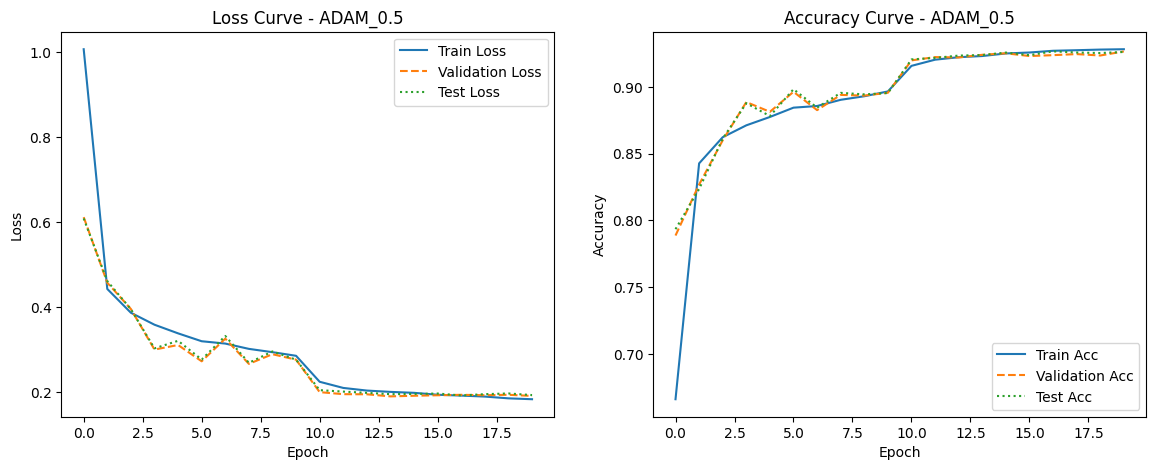

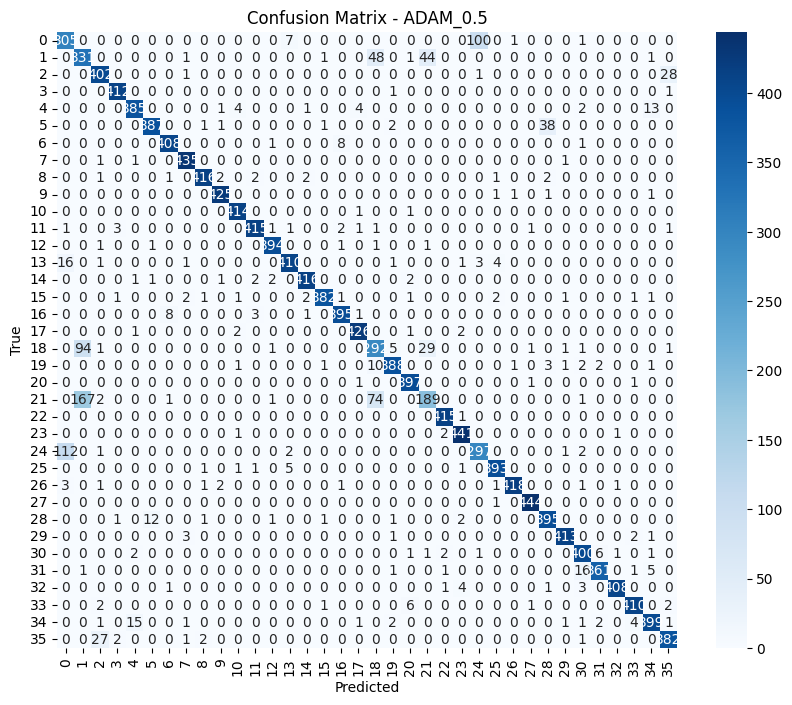

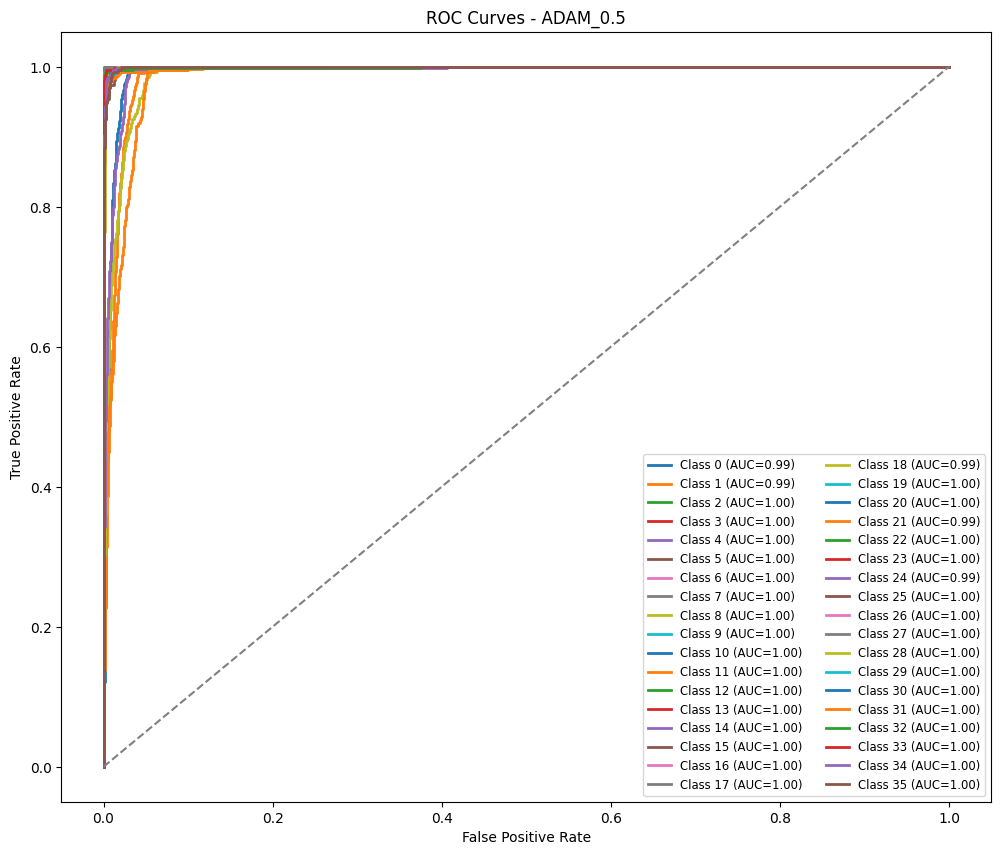


 Plotting results for SGD_0.5 ---


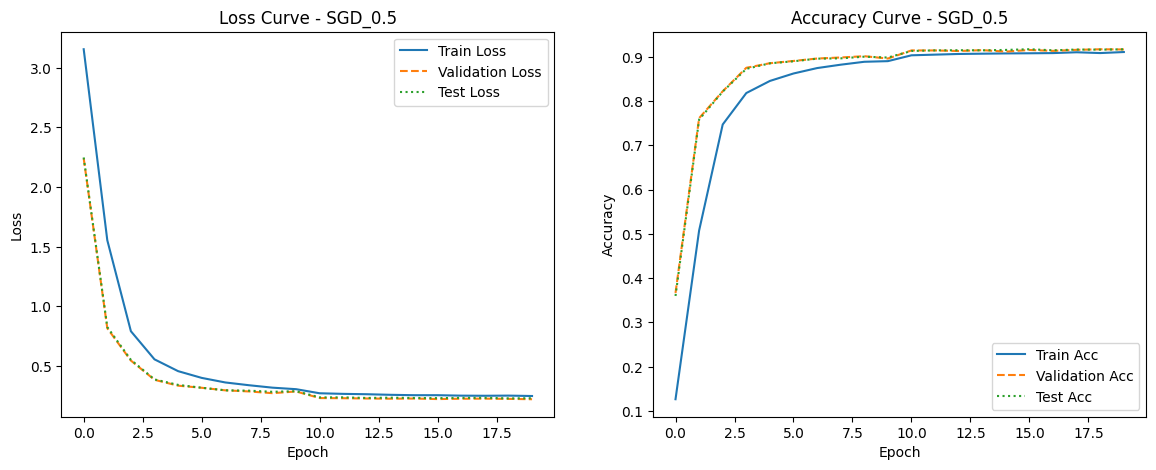

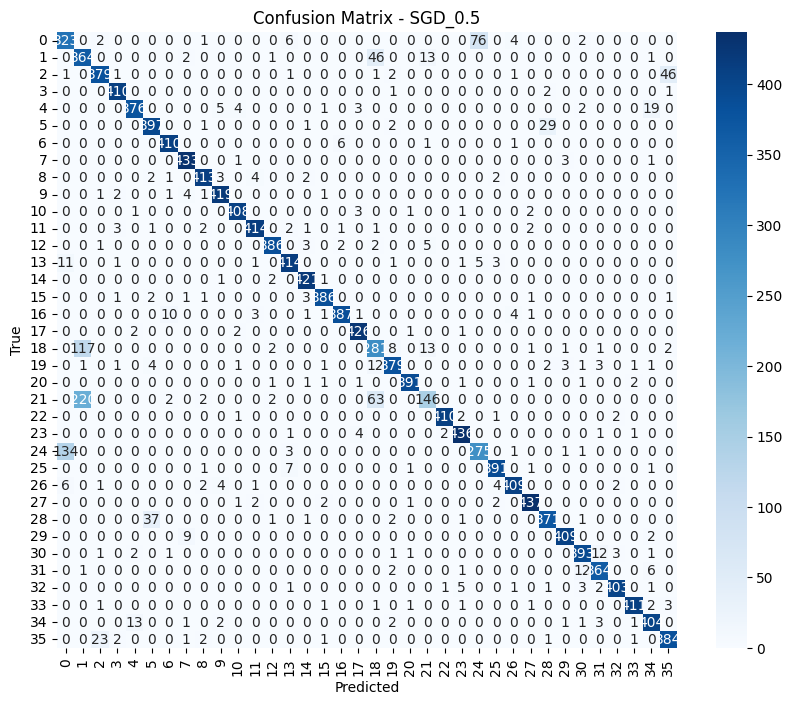

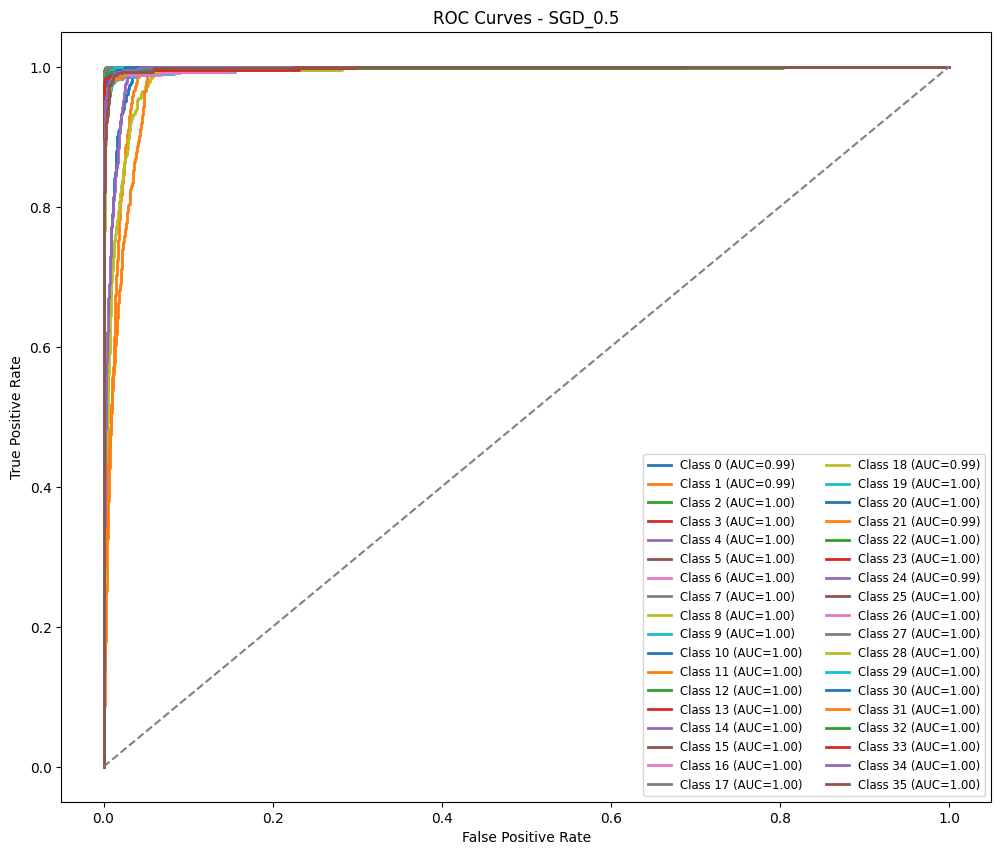


 Plotting results for RMSProp_0.5 ---


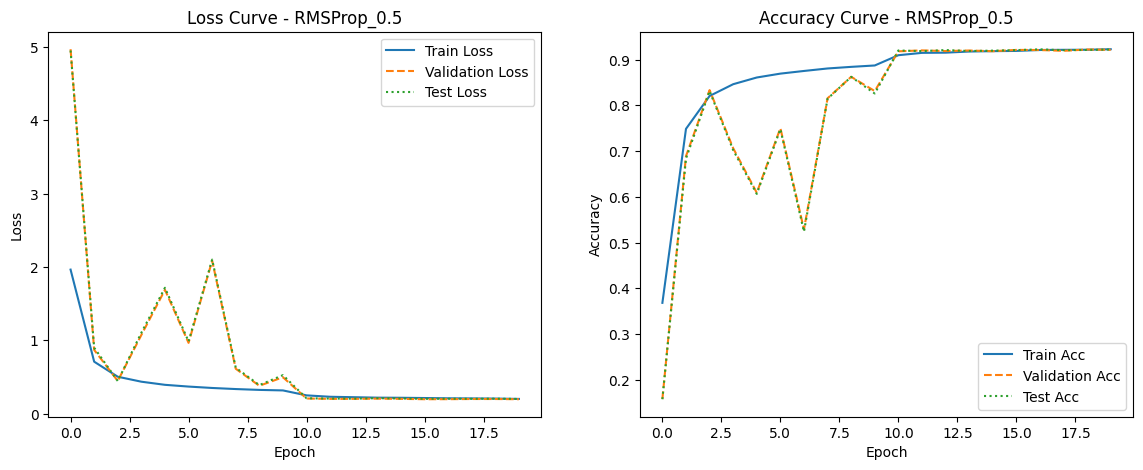

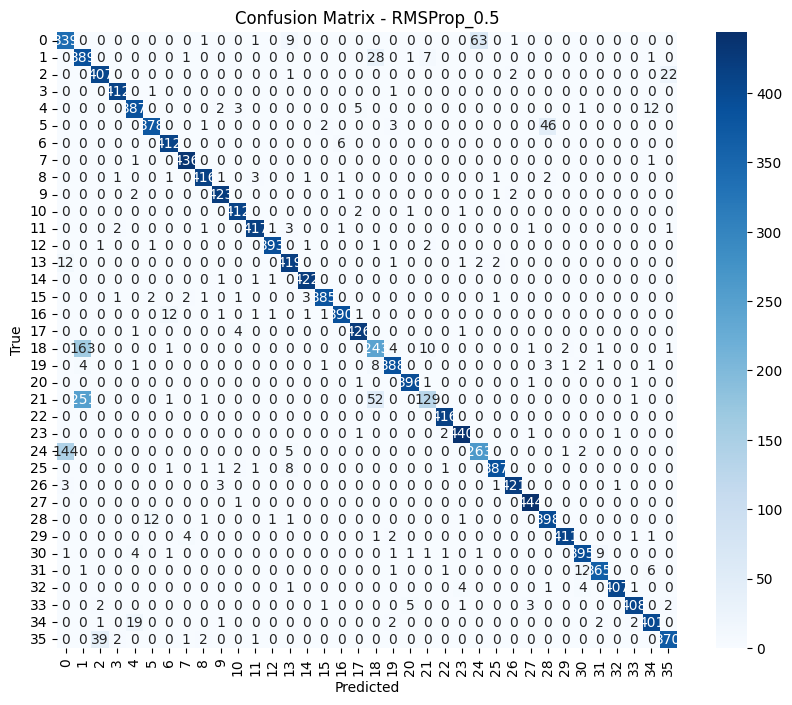

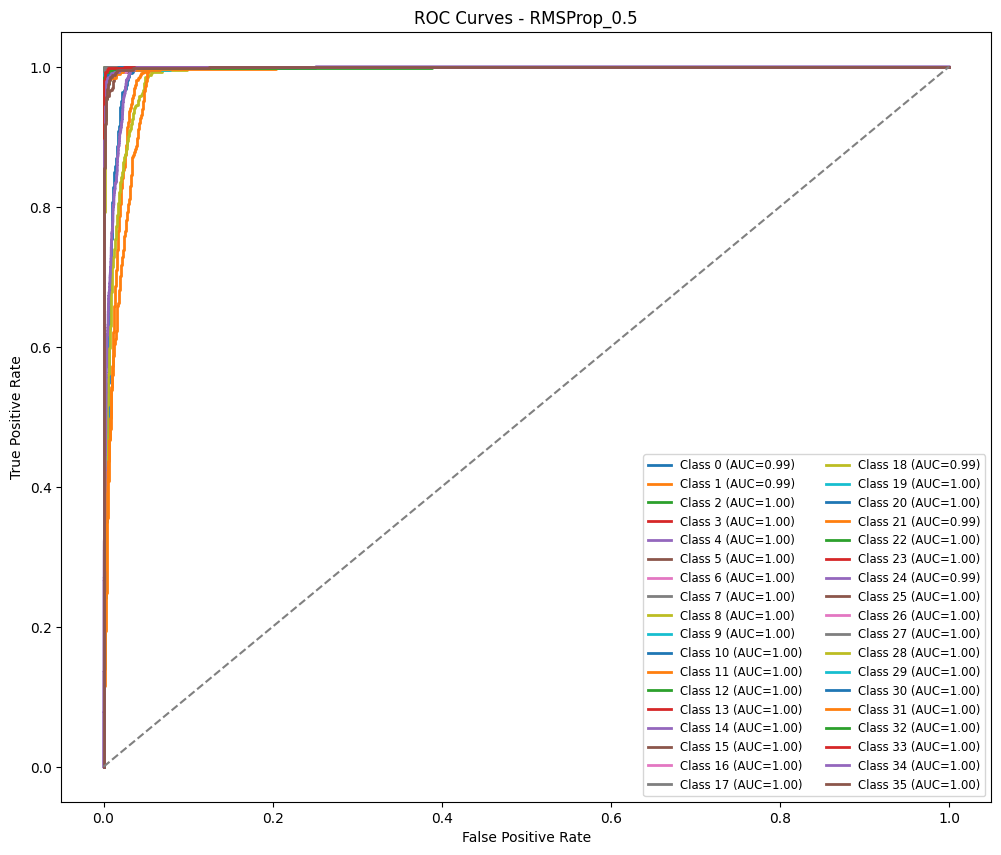

In [ ]:
for exp_name, metrics in results.items():
    print(f"\n Plotting results for {exp_name} ---")
    plot_model_results(metrics, num_classes=36)


In [ ]:
#saving best weight

#Adding dropout to improve the accuracy

In [ ]:
#droput
dropout_hyperparams = [
    {"name": "Dropout_0.3", "dropout": 0.3},
    {"name": "Dropout_0.7", "dropout": 0.7}

]

results_dropout = {}

for exp in dropout_hyperparams:
    print(f"\n--- Running Experiment: {exp['name']} ---")

    metrics = train_vgg(
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer_type='adam',
        dropout_rate=exp['dropout'],
        num_epochs=10,
        model_name=exp['name']
    )

    results_dropout[exp['name']] = metrics



--- Running Experiment: Dropout_0.3 ---
[Dropout_0.3] Epoch 1/10 | Train Acc: 0.7084 | Val Acc: 0.8118 | Test Acc: 0.8091 | Train Loss: 0.8669 | Val Loss: 0.5224 | Test Loss: 0.5351
[Dropout_0.3] Epoch 2/10 | Train Acc: 0.8581 | Val Acc: 0.8849 | Test Acc: 0.8840 | Train Loss: 0.3931 | Val Loss: 0.3245 | Test Loss: 0.3324
[Dropout_0.3] Epoch 3/10 | Train Acc: 0.8733 | Val Acc: 0.8017 | Test Acc: 0.7952 | Train Loss: 0.3497 | Val Loss: 0.5731 | Test Loss: 0.5885
[Dropout_0.3] Epoch 4/10 | Train Acc: 0.8812 | Val Acc: 0.8634 | Test Acc: 0.8645 | Train Loss: 0.3191 | Val Loss: 0.3669 | Test Loss: 0.3715
[Dropout_0.3] Epoch 5/10 | Train Acc: 0.8854 | Val Acc: 0.8756 | Test Acc: 0.8744 | Train Loss: 0.3099 | Val Loss: 0.3519 | Test Loss: 0.3537
[Dropout_0.3] Epoch 6/10 | Train Acc: 0.8913 | Val Acc: 0.8885 | Test Acc: 0.8913 | Train Loss: 0.2931 | Val Loss: 0.2866 | Test Loss: 0.2835
[Dropout_0.3] Epoch 7/10 | Train Acc: 0.8950 | Val Acc: 0.8870 | Test Acc: 0.8878 | Train Loss: 0.2833 | Va


 Plotting results for Dropout_0.3 ---


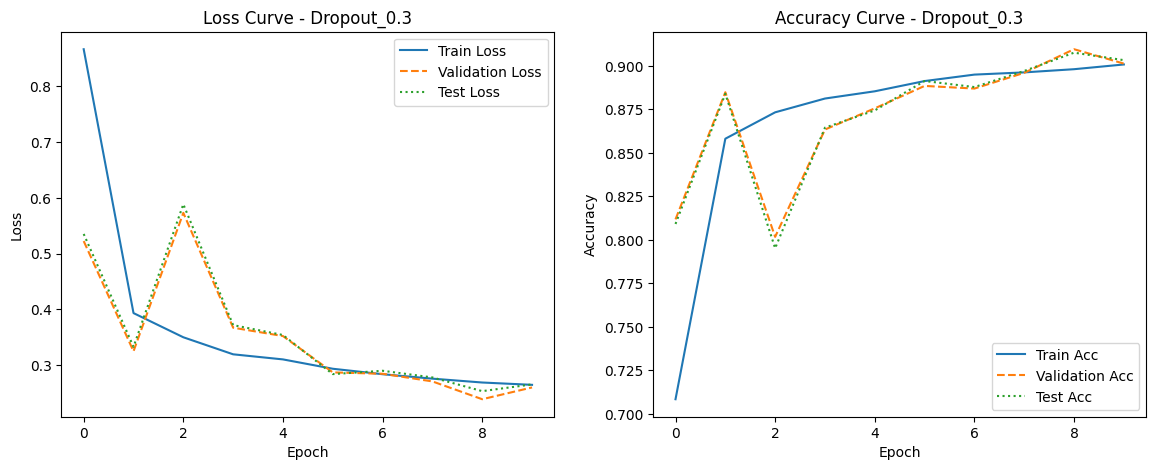

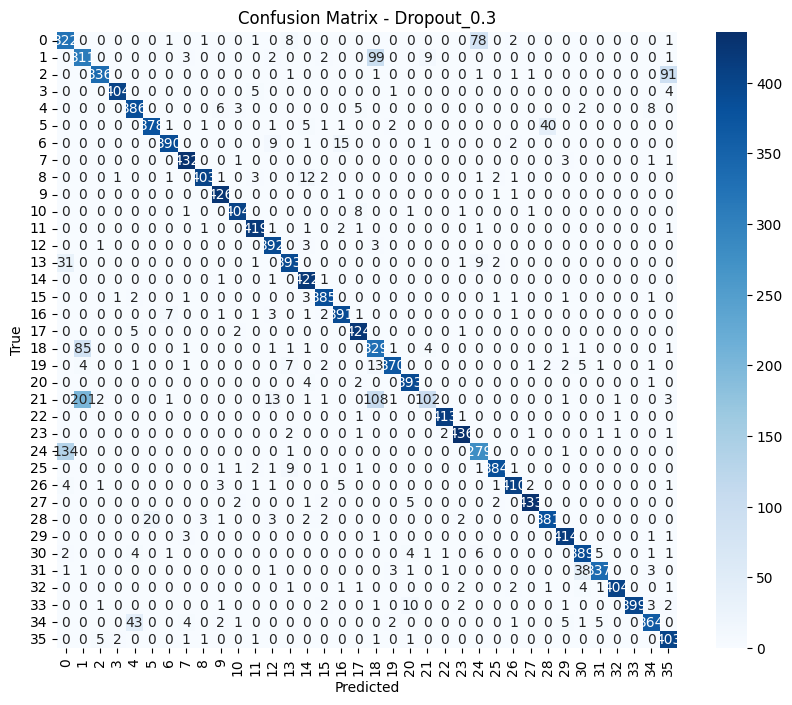

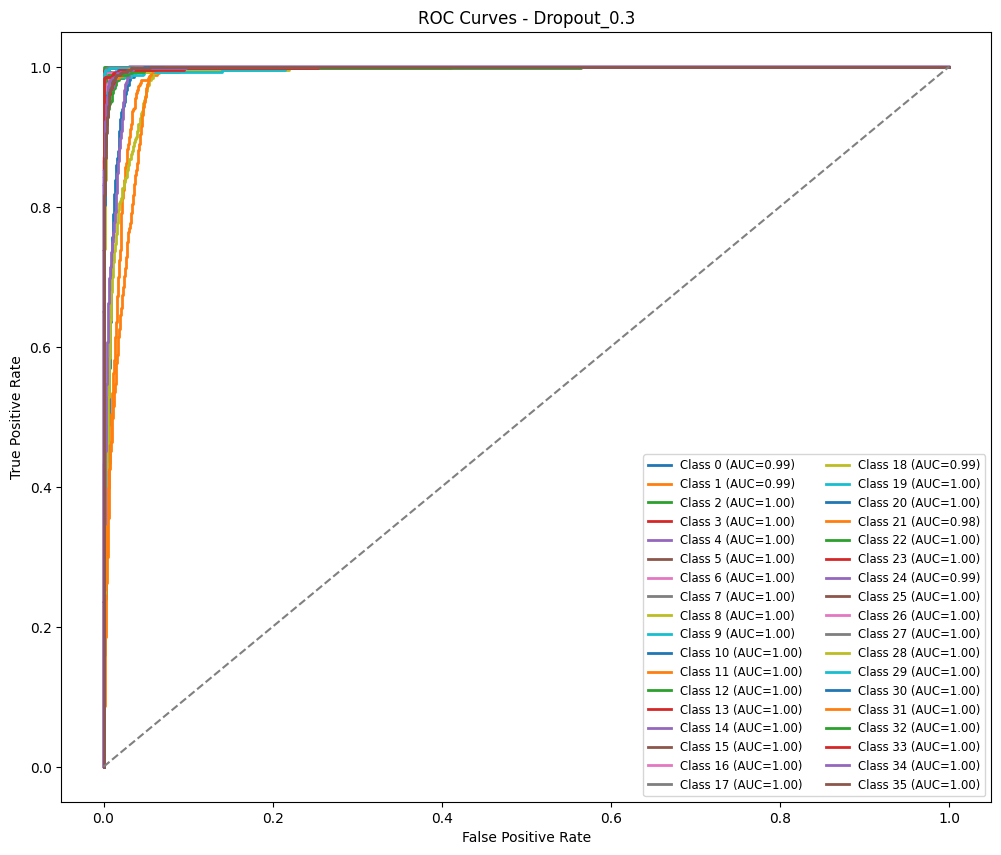


 Plotting results for Dropout_0.7 ---


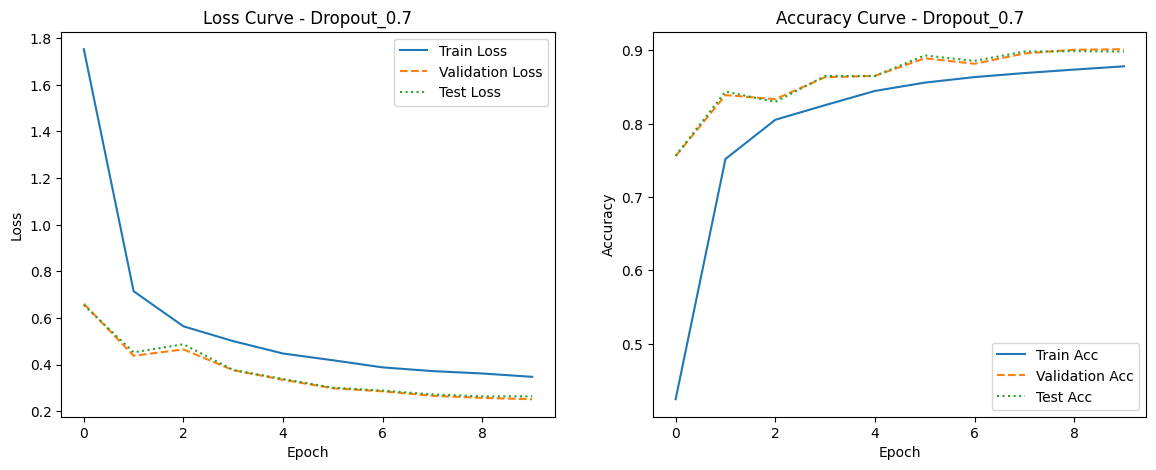

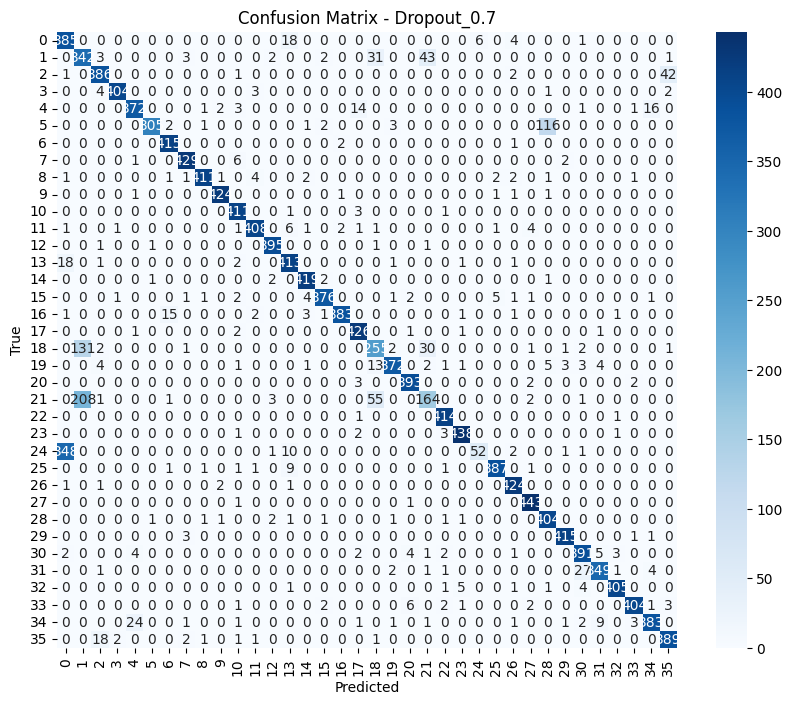

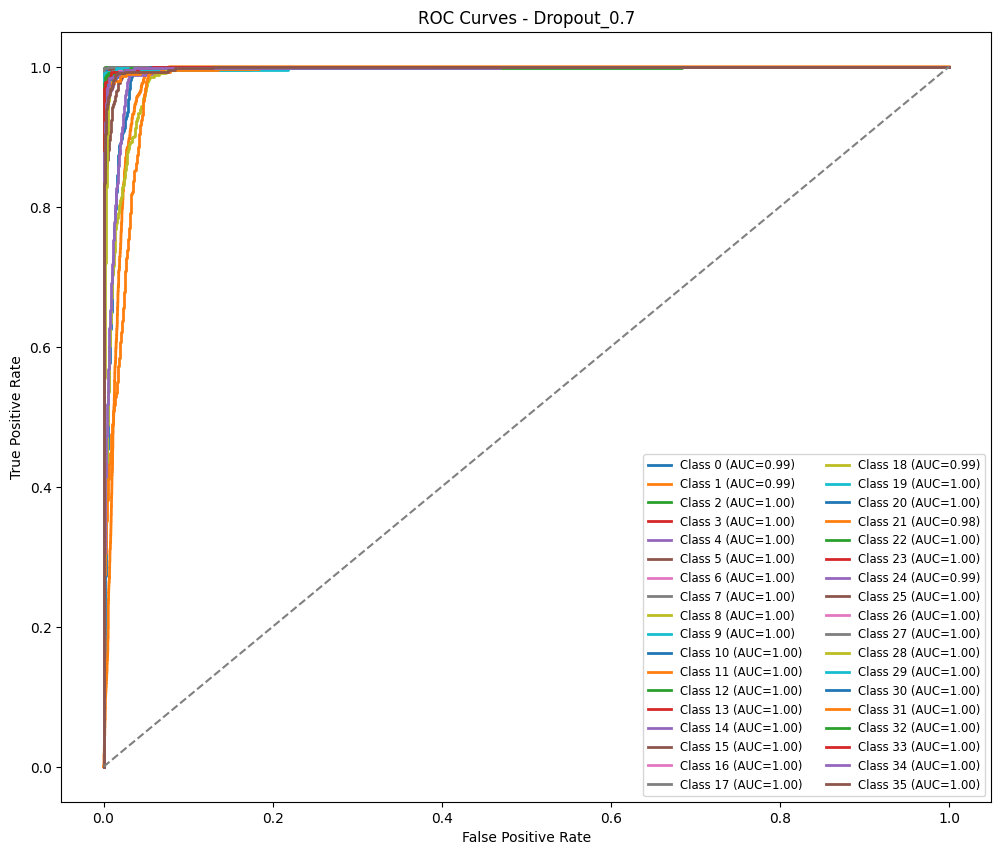

In [ ]:
for exp_name, metrics in results_dropout.items():
    print(f"\n Plotting results for {exp_name} ---")
    plot_model_results(metrics, num_classes=36)

##Adding early stoppage to the best result parameters

In [ ]:
early_stop = [
    {"name": "EarlyStop_4", "early_stop": True, "patience": 4},
    {"name": "EarlyStop_7", "early_stop": True, "patience": 7},
]

In [ ]:
results_early_stop = {}

for exp in early_stop:
    print(f"\n--- Running : {exp['name']} ---")

    metrics = train_vgg(
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer_type='adam',
        dropout_rate=0.7,
        early_stopping=exp['early_stop'],
        patience=exp['patience'],
        num_epochs=10,
        model_name=exp['name']
    )

    results_early_stop[exp['name']] = metrics


--- Running : EarlyStop_4 ---
[EarlyStop_4] Epoch 1/10 | Train Acc: 0.4507 | Val Acc: 0.6992 | Test Acc: 0.6966 | Train Loss: 1.6681 | Val Loss: 0.8440 | Test Loss: 0.8475
[EarlyStop_4] Epoch 2/10 | Train Acc: 0.7544 | Val Acc: 0.8280 | Test Acc: 0.8273 | Train Loss: 0.7158 | Val Loss: 0.4522 | Test Loss: 0.4518
[EarlyStop_4] Epoch 3/10 | Train Acc: 0.8070 | Val Acc: 0.8540 | Test Acc: 0.8525 | Train Loss: 0.5583 | Val Loss: 0.3760 | Test Loss: 0.3830
[EarlyStop_4] Epoch 4/10 | Train Acc: 0.8272 | Val Acc: 0.8776 | Test Acc: 0.8764 | Train Loss: 0.4941 | Val Loss: 0.3307 | Test Loss: 0.3350
[EarlyStop_4] Epoch 5/10 | Train Acc: 0.8399 | Val Acc: 0.8661 | Test Acc: 0.8649 | Train Loss: 0.4548 | Val Loss: 0.3690 | Test Loss: 0.3889
[EarlyStop_4] Epoch 6/10 | Train Acc: 0.8514 | Val Acc: 0.8771 | Test Acc: 0.8765 | Train Loss: 0.4274 | Val Loss: 0.3495 | Test Loss: 0.3544
[EarlyStop_4] Epoch 7/10 | Train Acc: 0.8593 | Val Acc: 0.8667 | Test Acc: 0.8630 | Train Loss: 0.3989 | Val Loss: 0.

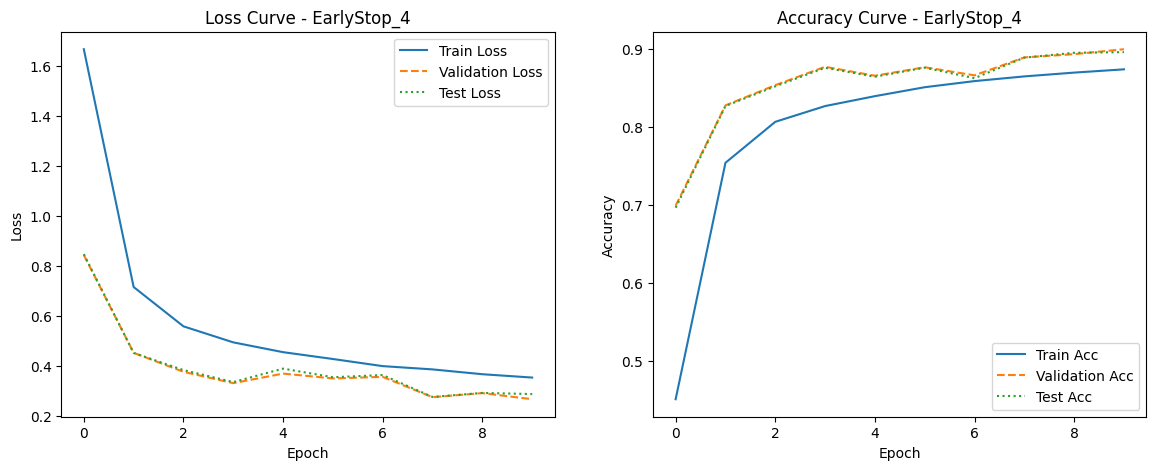

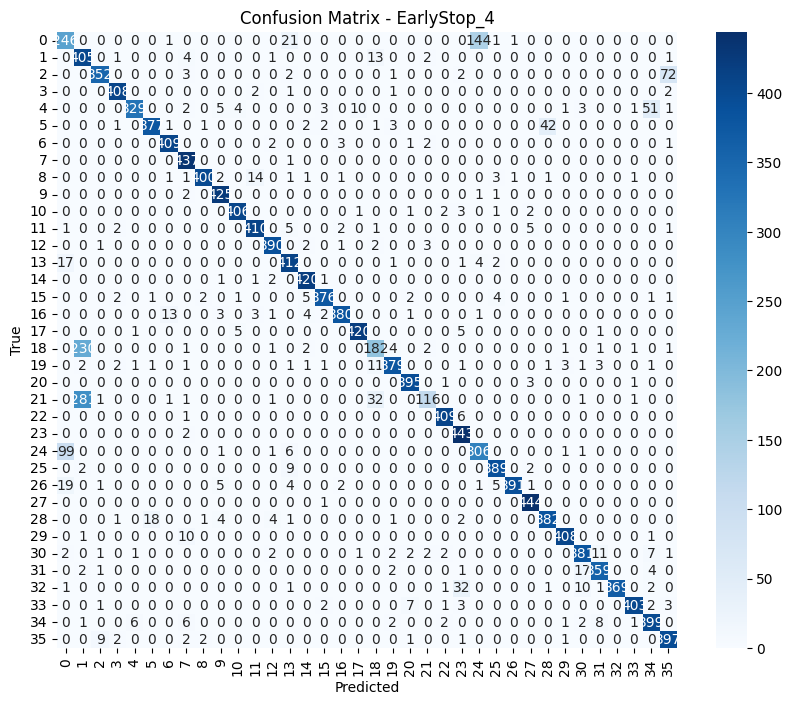

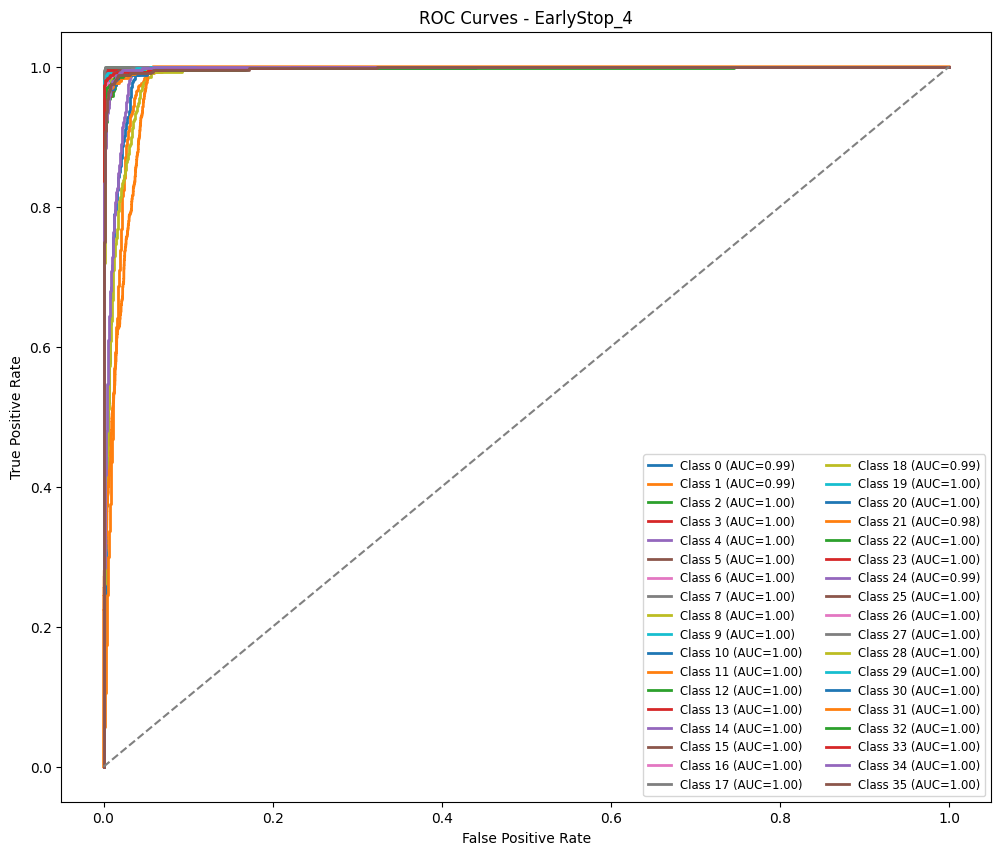

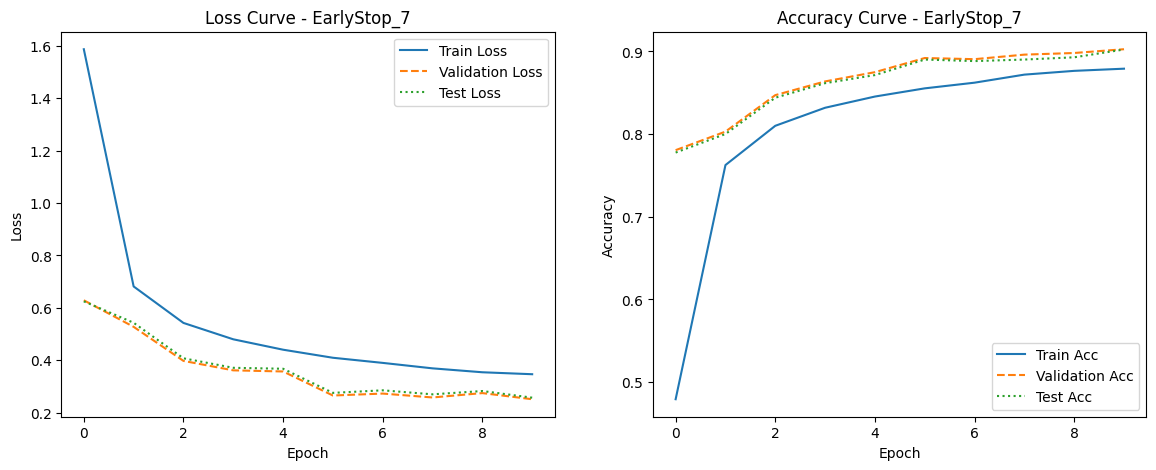

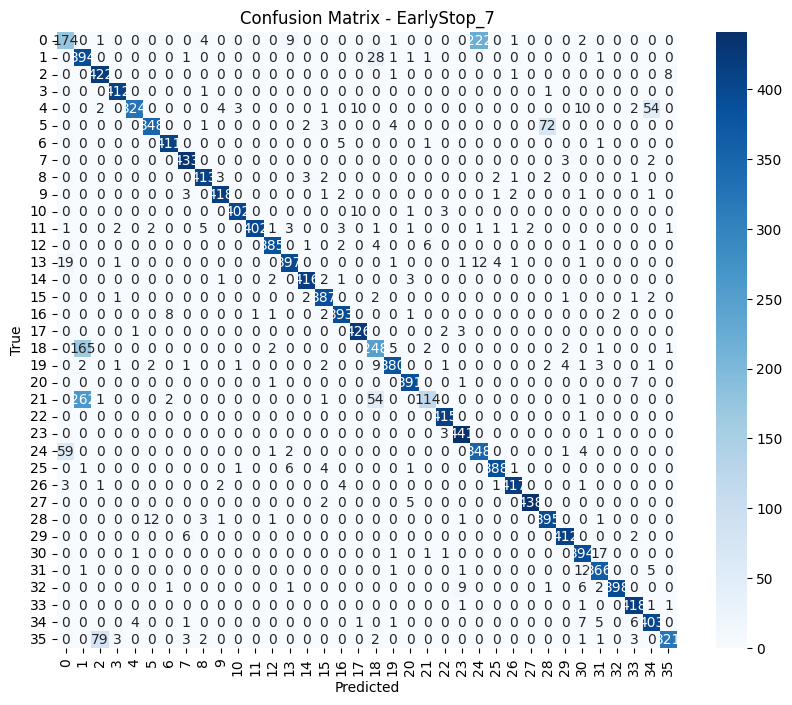

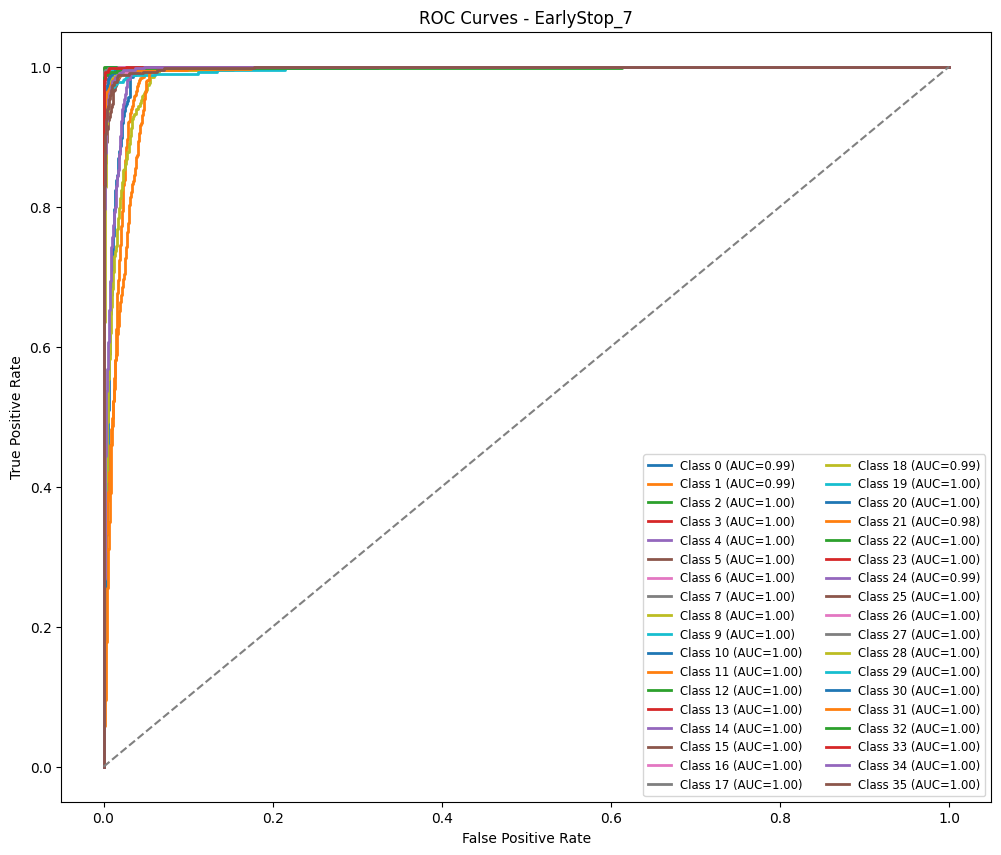

In [ ]:
for exp_name, metrics in results_early_stop.items():
    plot_model_results(metrics, num_classes=36)


#So far we got the best result from adam being our optimizer with learning rate as 0.001 and droprate as 0.5 for 20 epochs> Saving the weight

In [ ]:
# results['ADAM_0.5']

torch.save(results['ADAM_0.5'], "a2_part_4_weights_pradeep_aniket")


In [ ]:
import pickle
with open("a2_part_4_weights_pradeep_aniket", 'wb') as f:
  pickle.dump(results['ADAM_0.5'], f)


Observation : our test and validation curves are really close to each other and the highest test accuracy of 0.9259

#BONUS

In [ ]:
#building resnet-34
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- helper conv functions ---
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)

def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

In [ ]:




class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        # first conv3x3
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        # second conv3x3
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # downsample if needed
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out







In [ ]:

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000, in_channels=3, norm_layer=None, dropout=0.5):

        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer
        self.inplanes = 64
        self.dropout = dropout


        self.conv1 = nn.Conv2d(in_channels, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, 64,  layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)


        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        if self.dropout and self.dropout > 0.0:
            self.classifier = nn.Sequential(
                nn.Dropout(p=self.dropout),
                nn.Linear(512 * block.expansion, num_classes)
            )
        else:
            self.classifier = nn.Linear(512 * block.expansion, num_classes)

        # initialize weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # kaiming normal (recommended for ReLU)
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = 1

        if stride != 1 or self.inplanes != planes * block.expansion:
            # downsample with 1x1 conv to match dimensions
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Input shape: (B, C, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)  # size reduced per layer's stride
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)  # (B, 512, 1, 1)
        x = torch.flatten(x, 1)  # (B, 512)
        x = self.classifier(x)
        return x

In [ ]:

def resnet34(num_classes=1000, in_channels=3, dropout=0.0):

    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, in_channels=in_channels, dropout=dropout)

In [ ]:
!ls

sample_data


In [ ]:
# After importing
import zipfile, os

zip_path = "flowers.zip"  # change name if different
extract_path = "flowers"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['flowers']

In [ ]:
#importing the files
import os
import shutil
from scipy.io import loadmat
from tqdm import tqdm


base_dir = "flowers/flowers"
image_dir = os.path.join(base_dir, "jpg")
out_dir = base_dir



labels_data = loadmat(os.path.join(base_dir, "imagelabels.mat"))
setid_data  = loadmat(os.path.join(base_dir, "setid.mat"))

labels = labels_data["labels"][0]
train_ids = setid_data["trnid"][0]
val_ids   = setid_data["valid"][0]
test_ids  = setid_data["tstid"][0]

print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")


splits = ["train", "val", "test"]
for split in splits:
    for c in range(1, 103):
        os.makedirs(os.path.join(out_dir, split, f"class_{c:03d}"), exist_ok=True)


def copy_images(indices, split):
    for idx in tqdm(indices, desc=f"Copying {split}"):
        img_name = f"image_{idx:05d}.jpg"
        src = os.path.join(image_dir, img_name)
        label = labels[idx - 1]  # label starts from 1
        dst = os.path.join(out_dir, split, f"class_{label:03d}", img_name)
        shutil.copy(src, dst)


copy_images(train_ids, "train")
copy_images(val_ids, "val")
copy_images(test_ids, "test")




Train: 1020, Val: 1020, Test: 6149


Copying test: 100%|██████████| 6149/6149 [00:00<00:00, 9432.25it/s]


In [ ]:
!ls flowers/flowers

imagelabels.mat  jpg  setid.mat  test  train  val


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
}

train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), transform=data_transforms['train'])
val_dataset   = datasets.ImageFolder(os.path.join(base_dir, 'val'), transform=data_transforms['val'])
test_dataset  = datasets.ImageFolder(os.path.join(base_dir, 'test'), transform=data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 32, Val batches: 32, Test batches: 193


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def train_model(model,
                train_loader, val_loader, test_loader,
                criterion=nn.CrossEntropyLoss(),
                optimizer=None,
                scheduler=None,
                num_epochs=15,
                device='cuda',
                patience=10):


    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    trigger_times = 0

    train_losses, val_losses, test_losses = [], [], []
    train_accs, val_accs, test_accs = [], [], []

    y_true_test, y_pred_test, y_probs_test = [], [], []

    for epoch in range(num_epochs):

        model.train()
        running_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        if scheduler:
            scheduler.step()


        model.eval()
        running_val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = running_val_loss / total_val
        val_acc = correct_val / total_val
        val_losses.append(val_loss)
        val_accs.append(val_acc)


        running_test_loss, correct_test, total_test = 0, 0, 0
        y_true_epoch, y_pred_epoch, y_probs_epoch = [], [], []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct_test += (preds == labels).sum().item()
                total_test += labels.size(0)

                y_true_epoch.extend(labels.cpu().numpy())
                y_pred_epoch.extend(preds.cpu().numpy())
                y_probs_epoch.extend(torch.softmax(outputs, dim=1).cpu().numpy())

        test_loss = running_test_loss / total_test
        test_acc = correct_test / total_test
        test_losses.append(test_loss)
        test_accs.append(test_acc)


        y_true_test, y_pred_test, y_probs_test = y_true_epoch, y_pred_epoch, y_probs_epoch

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Test Loss: {test_loss:.4f}")


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), "best_model.pth")  # save best model
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    metrics = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'test_loss': test_losses,
        'train_acc': train_accs,
        'val_acc': val_accs,
        'test_acc': test_accs,
        'y_true': y_true_test,
        'y_pred': y_pred_test,
        'y_probs': y_probs_test,
        'model': model
    }

    return metrics


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet34(num_classes=102).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)


In [ ]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)


In [ ]:
metrics = train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=15,
    device=device,
    patience=10
)

Epoch [1/15] | Train Acc: 0.0225 | Val Acc: 0.0294 | Test Acc: 0.0195 | Val Loss: 19.7309 | Test Loss: 21.3390
Epoch [2/15] | Train Acc: 0.0549 | Val Acc: 0.0510 | Test Acc: 0.0376 | Val Loss: 5.2307 | Test Loss: 5.6708
Epoch [3/15] | Train Acc: 0.1069 | Val Acc: 0.0696 | Test Acc: 0.0712 | Val Loss: 4.1332 | Test Loss: 4.1972
Epoch [4/15] | Train Acc: 0.0990 | Val Acc: 0.1147 | Test Acc: 0.1038 | Val Loss: 3.9371 | Test Loss: 4.0596
Epoch [5/15] | Train Acc: 0.1235 | Val Acc: 0.1039 | Test Acc: 0.1049 | Val Loss: 3.9222 | Test Loss: 4.0224
Epoch [6/15] | Train Acc: 0.1951 | Val Acc: 0.1637 | Test Acc: 0.1527 | Val Loss: 3.3540 | Test Loss: 3.5033
Epoch [7/15] | Train Acc: 0.2324 | Val Acc: 0.1951 | Test Acc: 0.1810 | Val Loss: 3.2401 | Test Loss: 3.3974
Epoch [8/15] | Train Acc: 0.2176 | Val Acc: 0.2157 | Test Acc: 0.1890 | Val Loss: 3.1985 | Test Loss: 3.3516
Epoch [9/15] | Train Acc: 0.2441 | Val Acc: 0.2137 | Test Acc: 0.1826 | Val Loss: 3.1775 | Test Loss: 3.3479
Epoch [10/15] | T

KeyboardInterrupt: 